In [2]:
from sqlite3 import connect
from bev2bytes import bytes2bev
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

In [15]:
with connect("D:/路口/PyCAVSim2/examples/following_test/ZS-0.mtsdb.meta") as con:
    cursor = con.cursor()
    # 获取configs表drivable和line两列的第一行内容，存储为变量gdb和glb
    cursor.execute("SELECT drivable, line FROM configs LIMIT 1")
    gdb, glb = cursor.fetchone()
    # 获取global表step==20的一行下vehicle这一列的内容，存储为变量gdv
    cursor.execute("SELECT vehicle FROM global WHERE step == 20")
    gdv = cursor.fetchone()[0]
    # 获取veh_00010表step==20的一行下drivable、line和vehicle这三列的内容，存储为变量ldb、lgb和lvb
    cursor.execute("SELECT drivable, line, vehicle FROM veh_00010 WHERE step == 20")
    ldb, lgb, lvb = cursor.fetchone()

In [17]:
global_bev = bytes2bev([gdb, glb, gdv], (81, 314), blen = (81 * 314 - 1) // 8 + 1)
local_bev = bytes2bev([ldb, lgb, lvb], (64, 64), blen = (64 * 64 - 1) // 8 + 1)


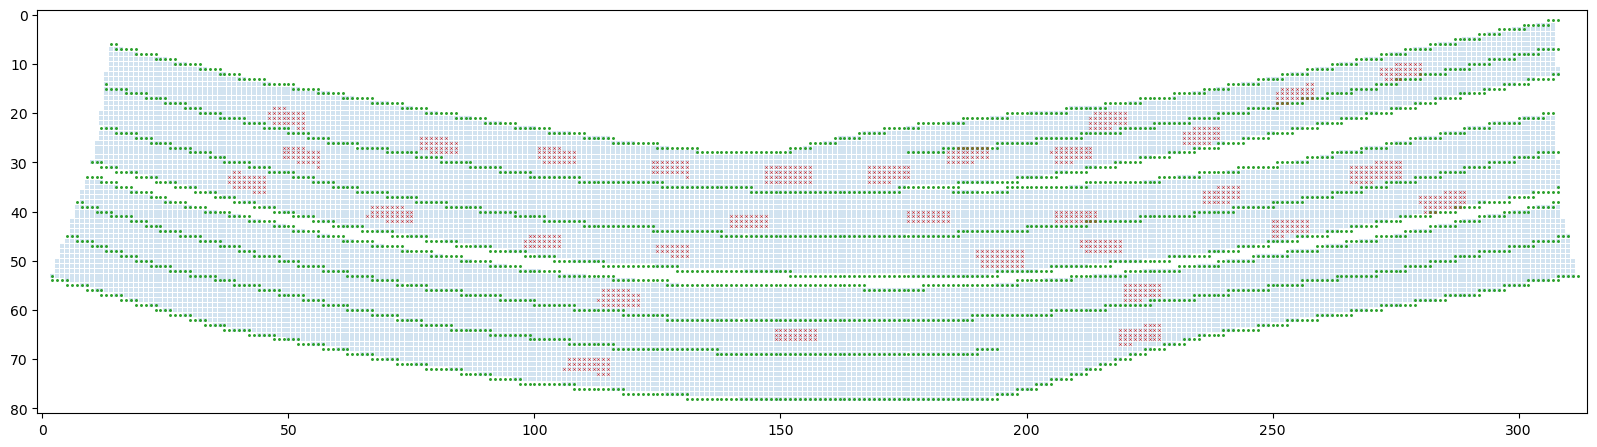

In [46]:
plt.figure(figsize = (20, 10))
plt.axis([-1, 314, -1, 81])
pi, pj = np.meshgrid(np.arange(81), np.arange(314), indexing = "ij")
plt.scatter(pj[global_bev[0]], pi[global_bev[0]], s = 5., marker = "s", linewidth = 0., alpha = .2, c = "C0")
plt.scatter(pj[global_bev[1]], pi[global_bev[1]], s = 5., marker = ".", linewidth = 1., c = "C2")
plt.scatter(pj[global_bev[2]], pi[global_bev[2]], s = 5., marker = "x", linewidth = .3, c = "C3")
# 翻转y轴
ax = plt.gca()
ax.invert_yaxis()
ax.set_aspect("equal")
plt.savefig("global_bev.pdf", bbox_inches = "tight")

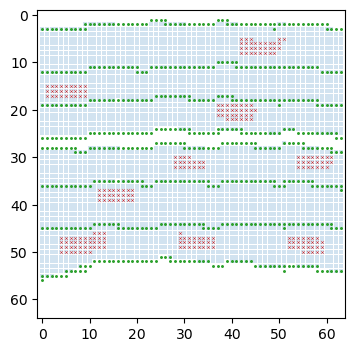

In [51]:
plt.figure(figsize = (4, 4))
plt.axis([-1, 64, -1, 64])
pi, pj = np.meshgrid(np.arange(64), np.arange(64), indexing = "ij")
plt.scatter(pj[local_bev[0]], pi[local_bev[0]], s = 5., marker = "s", linewidth = 0., alpha = .2, c = "C0")
plt.scatter(pj[local_bev[1]], pi[local_bev[1]], s = 5., marker = ".", linewidth = 1., c = "C2")
plt.scatter(pj[local_bev[2]], pi[local_bev[2]], s = 5., marker = "x", linewidth = .3, c = "C3")
# 翻转y轴
ax = plt.gca()
ax.invert_yaxis()
ax.set_aspect("equal")
plt.savefig("local_bev.pdf", bbox_inches = "tight")

In [20]:
pi, pj

(array([[ 0,  1,  2, ..., 78, 79, 80],
        [ 0,  1,  2, ..., 78, 79, 80],
        [ 0,  1,  2, ..., 78, 79, 80],
        ...,
        [ 0,  1,  2, ..., 78, 79, 80],
        [ 0,  1,  2, ..., 78, 79, 80],
        [ 0,  1,  2, ..., 78, 79, 80]]),
 array([[  0,   0,   0, ...,   0,   0,   0],
        [  1,   1,   1, ...,   1,   1,   1],
        [  2,   2,   2, ...,   2,   2,   2],
        ...,
        [311, 311, 311, ..., 311, 311, 311],
        [312, 312, 312, ..., 312, 312, 312],
        [313, 313, 313, ..., 313, 313, 313]]))

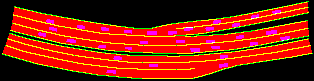

In [14]:
Image.fromarray(np.uint8(global_bev * 255).transpose(1, 2, 0))

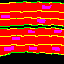

In [18]:
Image.fromarray(np.uint8(local_bev * 255).transpose(1, 2, 0))